<a href="https://colab.research.google.com/github/Clare-ctrl/music-genre-classification/blob/main/CS441_Final_Project_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS 441 (FA25) Final Project

Music Genre Classification with Frozen YAMNet Encoder and Fine-Tunes Classifier Head

# 1. Prepare dataset

In [ ]:
# The following code is for extracting tensorflow data. The data has 10 labels
# reference: https://github.com/tensorflow/datasets/blob/master/tensorflow_datasets/audio/gtzan/gtzan.py

In [ ]:
# Install TensorFlow Datasets
#!pip install tensorflow tensorflow-datasets
#!pip install tensorflow_hub tensorflow_io
# Installs
#!pip install resampy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 72.0 MB/s eta 0:00:00


In [ ]:
# Download the GTZAN Genre collection from here: https://www.kaggle.com/datasets/carlthome/gtzan-genre-collection?resource=download
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
# Extract zip file
import zipfile
zip_path = "/content/gdrive/MyDrive/CS 441 Homeworks/Final project/gtzan.zip"

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall("/content/gtzan")

print("Extracted!")

Extracted!


# 2. Setup data and labels into memory

## Define the label space



- Loaded 10 genre folders from /content/gtzan/genres

- Mapped each genre name → integer index (0–9)

This creates the target labels for classification.

In [ ]:
# Define labels: genre -> integer
import os
DATASET_DIR = "/content/gtzan/genres"
GENRES = sorted(os.listdir(DATASET_DIR))
GENRE_TO_INDEX = {g: i for i, g in enumerate(GENRES)}

print(GENRE_TO_INDEX)

{'blues': 0, 'classical': 1, 'country': 2, 'disco': 3, 'hiphop': 4, 'jazz': 5, 'metal': 6, 'pop': 7, 'reggae': 8, 'rock': 9}


## Load all audio into memory

For every GTZAN .au file:

-  Loaded the waveform using librosa.load()

- Appended the waveform to audio_list

- Appended its numeric label to label_list

Result:

- audio_list contains 1000 audio waveforms

- label_list contains 1000 genre labels

This is the raw dataset.

In [ ]:
# Load audio and label list into memory
import os
import librosa
import numpy as np

audio_list = []
label_list = []

for genre in GENRES:
    folder = os.path.join(DATASET_DIR, genre)
    print(genre, "->", len(os.listdir(folder)))

    for filename in os.listdir(folder):
        if filename.endswith(".au"):
            filepath = os.path.join(folder, filename)

            audio, sr = librosa.load(filepath, sr=None)

            audio_list.append(audio)
            label_list.append(GENRE_TO_INDEX[genre])

print("Loaded:", len(audio_list), "audio files")
print("Labels:", len(label_list))
print("Unique labels:", set(label_list))

blues -> 100
classical -> 100
country -> 100
disco -> 100
hiphop -> 100
jazz -> 100
metal -> 100
pop -> 100
reggae -> 100
rock -> 100
Loaded: 1000 audio files
Labels: 1000
Unique labels: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9}


# 3. Load three pre-trained encoders and extract embeddings

We want to test three different encoders:
- YAMNet
- TRILL
- VGGish

## 3a. Load YAMNet

YAMNet is a pretrained Google audio model.

- A TensorFlow Hub model (yamnet) is loaded

- A helper function converts audio → YAMNet mel spectrogram

This means you are using a pretrained frontend, which is much better than hand-made log-spectrograms.

YAMNet outputs:

- Event classification scores

- Feature embeddings (1024 dim)

- A mel-spectrogram (T × 64)

In [ ]:
# Approach is GTZAN audio --> frozen pretrained encoder --> pooled embeddings --> classifier
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import librosa

# Load pre-trained YAMNet encoder
yamnet_model = hub.load("https://tfhub.dev/google/yamnet/1")

# Extract YAMNet embeddings for each song
def extract_yamnet_embedding(audio, sr):
    """
    Args:
        audio: 1D numpy array
        sr: sample rate of the input audio
    Returns:
        YAMNet pooled mebedding (1024,)
    """
    if sr != 16000:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=16000)

    audio = tf.convert_to_tensor(audio, dtype=tf.float32)

    scores, embeddings, spectrogram = yamnet_model(audio)

    emb_np = embeddings.numpy()

    emb_ya = emb_np.mean(axis=0)

    return emb_ya

## 3a. Load TRILL

TRILL (Self-Supervised Acoustic Embedding Model)

TRILL is a self-supervised model trained on large-scale speech audio using contrastive learning.
Although originally designed for non-semantic speech tasks, TRILL captures rich acoustic information such as timbre, pitch contour, and spectral structure.

TRILL provides:
- Frame-level embeddings (e.g., 2048 dimensions)
- Averaged embeddings, which summarize the acoustic characteristics of a clip

These embeddings generalize well beyond speech and work moderately well for music tasks like GTZAN.

In [ ]:
# From Mengmeng
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import librosa

# Ensure the model is loaded (this part is correct)
trill = hub.load("https://tfhub.dev/google/nonsemantic-speech-benchmark/trill/3")

def extract_trill_embedding(audio, sr):

    TARGET_SR = 16000
    if sr != TARGET_SR:

        audio = librosa.resample(y=audio, orig_sr=sr, target_sr=TARGET_SR)
        sr = TARGET_SR

    audio = audio.astype(np.float32)

    audio_tensor = tf.constant(audio)[tf.newaxis, :]

    outputs = trill(samples=audio_tensor, sample_rate=tf.constant(sr, dtype=tf.int32))

    # Embedding shape typically (1, T, 512)
    emb = outputs["embedding"]

    # Pool across time
    pooled_emb = tf.reduce_mean(emb, axis=1)

    # Remove the batch dimension to get shape (512,)
    emb_tr = pooled_emb.numpy().flatten()

    return emb_tr

## 3c. Load VGGish

VGGish (Audio Embedding Model Trained on YouTube-8M)

VGGish is based on the VGG CNN architecture and trained on YouTube-8M, a large audiovisual dataset.
It includes many everyday sounds and musical content, making it useful for general audio recognition.

VGGish outputs:
- 96-frame patches, each with 128-dimensional embeddings
- A final 128-dimensional pooled embedding ← used in our classifier

VGGish provides compact, efficient audio representations and serves as a strong classical baseline for comparison.


In [ ]:
# From Mengmeng
import tensorflow_hub as hub
import tensorflow as tf
import numpy as np
import librosa
import resampy

vggish = hub.load("https://tfhub.dev/google/vggish/1")
print("VGGish loaded!")

def preprocess_for_vggish(audio, sr):
    # 1. Resample to 16k
    if sr != 16000:
        audio = resampy.resample(audio, sr, 16000)

    # 2. Convert to TF tensor
    audio_tensor = tf.constant(audio, dtype=tf.float32)[tf.newaxis, :]

    return audio_tensor

def extract_vggish_embedding(filepath):
    # Load audio
    audio, sr = librosa.load(filepath, sr=None)

    # 1. VGGish requires 16 kHz audio
    if sr != 16000:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=16000)

    # 2. Convert to float32 tensor WITHOUT extra dimensions
    audio_tensor = tf.constant(audio, dtype=tf.float32)   # shape (N,)

    # 3. Forward pass through VGGish
    outputs = vggish(audio_tensor)  # VGGish handles framing internally

    # 4. Convert to numpy
    emb = outputs.numpy()  # shape (num_patches, 128)

    # 5. Pool over time to get fixed-size vector
    emb_vgg = emb.mean(axis=0)       # shape (128,)

    return emb_vgg

VGGish loaded!


# 4. Setup ability to pick different encoders

Our new pipeline is:

- audio
- YAMNet (frozen pretrained encoder)
- embedding
- trainable classifier

So, we have no CNN, no spectrogram padding, and no convolutional layers
- YAMNet replaces CNN
- Mel specs are not needed manually
- CNN code is not used/deleted

In [ ]:
# Pick different pre-train models
def extract_embedding(filepath, model):
    audio, sr = librosa.load(filepath, sr=None)

    if model == "yamnet":
        return extract_yamnet_embedding(audio, sr)

    elif model == "trill":
        return extract_trill_embedding(audio, sr)

    elif model == "vggish":
        return extract_vggish_embedding(filepath)

    else:
        raise ValueError("Unknown model name")

# 5. Setup training and validation sets

You split the embeddings using train/validation (70%/30%), stratified by label.

Dataset is ready for classification.

This will convert embeddings and labels into numpy arrays

In [ ]:
# From Mengmeng
# Get accuracy for pretrain-models
import os
from sklearn.model_selection import train_test_split

def pretrain_to_data(model, directory):
    X = []
    y = []

    GENRES = sorted(os.listdir(directory))
    GENRE_TO_INDEX = {g: i for i, g in enumerate(GENRES)}

    for genre in GENRES:
        folder = os.path.join(directory, genre)
        #print("Processing genre:", genre)

        for filename in os.listdir(folder):
            if filename.endswith(".au"):
                filepath = os.path.join(folder, filename)

                # Unified embedding extraction
                emb = extract_embedding(filepath, model)

                X.append(emb)
                y.append(GENRE_TO_INDEX[genre])

    X = np.array(X)
    y = np.array(y)

    x_train, x_val, y_train, y_val = train_test_split(
        X, y,
        test_size=0.3,
        stratify=y,
        random_state=42
    )

    return x_train, x_val, y_train, y_val, X, y

## Visualize embeddings with t-SNE

This creates a 2-dimensional visual map of all the GTZAN songs using the YAMNet embeddings
- reduce dimensions to show clusters
- YAMNet output is 1024-dimensional vectors and reduce to 2 dimensions

In [ ]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

❗ This will take about 6 minutes.

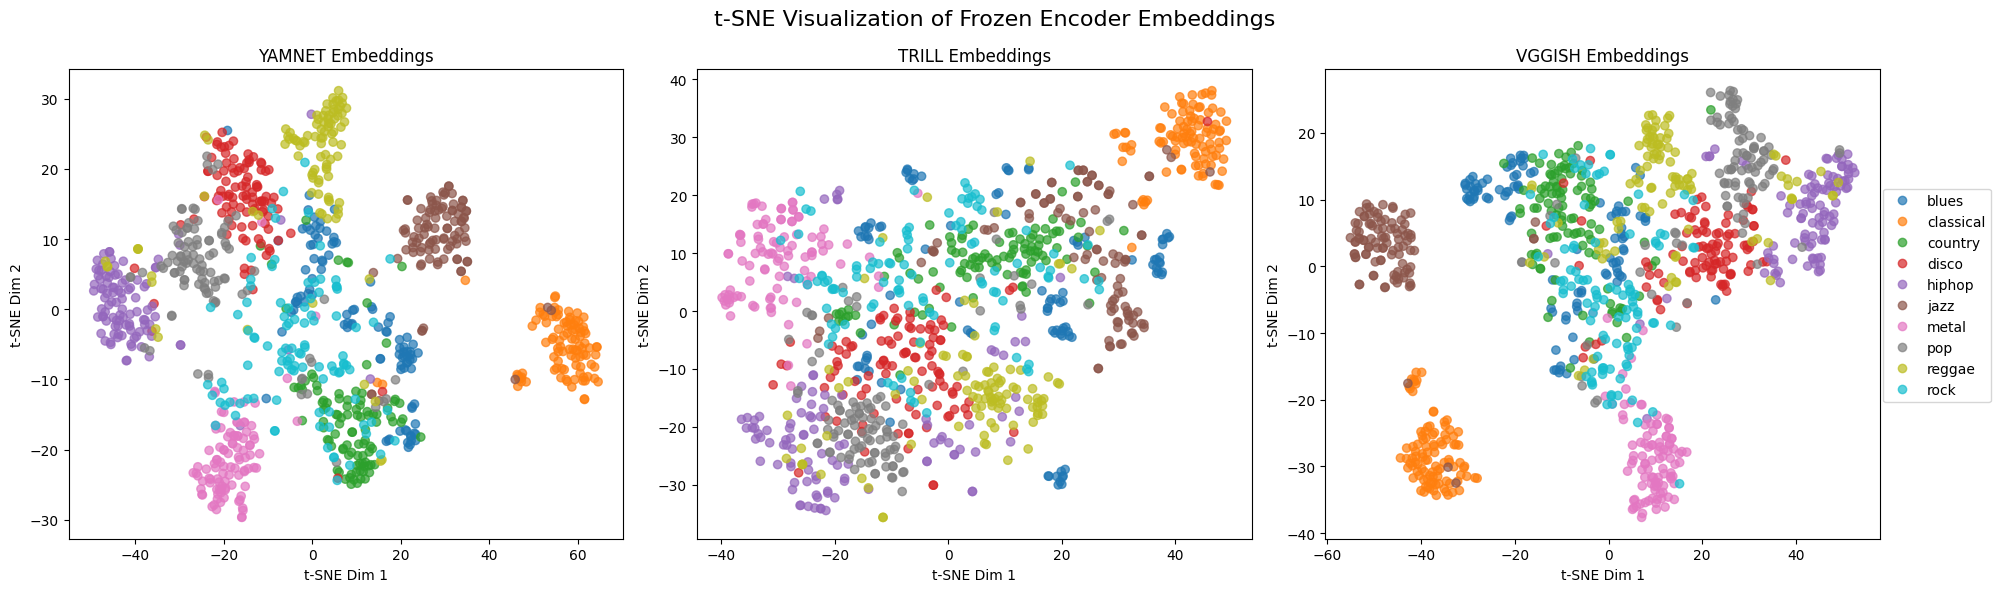

In [ ]:
# tSNE visualization for all three encoders
encoders = ["yamnet", "trill", "vggish"]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, encoder_name in zip(axes, encoders):
    # Get embeddings for this encoder
    _, _, _, _, X, y = pretrain_to_data(
        model=encoder_name,
        directory=DATASET_DIR
    )

    # t-SNE projection
    tsne = TSNE(
        n_components=2,
        init="pca",
        learning_rate="auto",
        random_state=42
    )
    X_2d = tsne.fit_transform(X)

    # Scatter plot
    scatter = ax.scatter(
        X_2d[:, 0],
        X_2d[:, 1],
        c=y,
        cmap="tab10",
        alpha=0.7
    )

    ax.set_title(f"{encoder_name.upper()} Embeddings")
    ax.set_xlabel("t-SNE Dim 1")
    ax.set_ylabel("t-SNE Dim 2")

# Shared legend
handles, _ = scatter.legend_elements()
fig.legend(handles, GENRES, loc="center right")
plt.suptitle("t-SNE Visualization of Frozen Encoder Embeddings", fontsize=16)
plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.show()


## 6. Train classifier on the three encoders

Logistic Regression will be used to learn to map the encoder embeddings to one of 10 genres.
- fitting the model will learn the decision boundaries between genres
- `clf.fit` will only train the classifier

Why Logisitic Regression?
- works well with high-dimensional embeddings
- trains fast
- good baseline accuracy
- commonly used to evaluate quality of embeddings

Here, we have our trainable head in our "frozen encoder + classifier" architecture

Evaluating the classifier with tell us how well it generalizes to unseen songs

## 6a. Train with sklearn logistic regression

❗ This will take about 5 minutes.

In [ ]:
# From Mengmeng
import time
from sklearn.linear_model import LogisticRegression

models = ["yamnet", "trill", "vggish"]
directory = "/content/gtzan/genres"

accuracies = {}
embedding_shapes = {}
runtimes = {}

for m in models:
    print(f"\n=== Evaluating {m.upper()} ===")

    start = time.time()   # start timing

    # Extract embeddings + train/val split
    x_train, x_val, y_train, y_val, X, y = pretrain_to_data(m, directory)

    # Record embedding shape
    embedding_shapes[m] = X[0].shape

    # Train linear classifier
    clf = LogisticRegression(max_iter=2000)
    clf.fit(x_train, y_train)

    # Accuracy
    acc = clf.score(x_val, y_val)
    accuracies[m] = acc

    # End timing
    end = time.time()
    runtimes[m] = end - start

    # Print results
    print(f"Embedding shape: {embedding_shapes[m]}")
    print(f"Accuracy: {acc*100:.2f}%")
    print(f"Runtime: {runtimes[m]:.2f} seconds")


=== Evaluating YAMNET ===
Embedding shape: (1024,)
Accuracy: 83.67%
Runtime: 29.24 seconds

=== Evaluating TRILL ===
Embedding shape: (512,)
Accuracy: 75.67%
Runtime: 219.74 seconds

=== Evaluating VGGISH ===
Embedding shape: (128,)
Accuracy: 84.67%
Runtime: 31.11 seconds


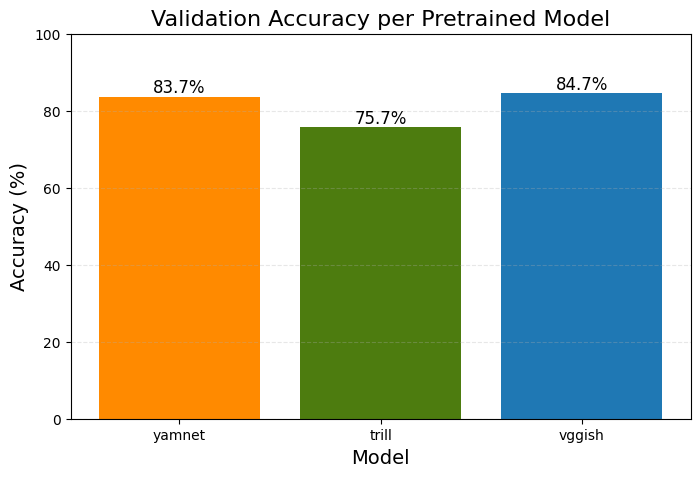

In [ ]:
import matplotlib.pyplot as plt

# Prepare data
model_names = list(accuracies.keys())
acc_values = [accuracies[m] * 100 for m in model_names]  # convert to %
colors = ["#ff8a00", "#4d7c0f", "#1f78b4"]  # optional colors

plt.figure(figsize=(8,5))
plt.bar(model_names, acc_values, color=colors)

# Labels
plt.title("Validation Accuracy per Pretrained Model", fontsize=16)
plt.xlabel("Model", fontsize=14)
plt.ylabel("Accuracy (%)", fontsize=14)

# Accuracy labels on bars
for i, v in enumerate(acc_values):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center', fontsize=12)

plt.ylim(0, 100)
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

For each genre (class):
- precision: among all songs predicted as this genre, how many were correct?
- recall: among all real songs of this genre, how many did the model correctly identify?
- f1 score that is combined measure of precision and recall
- support: how many validation samples belong to this genre?

In [ ]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

❗ This will take about 5 minutes.


Evaluating encoder: YAMNET

Validation Accuracy (YAMNET): 0.8367

Classification Report:
              precision    recall  f1-score   support

       blues     0.8966    0.8667    0.8814        30
   classical     0.9655    0.9333    0.9492        30
     country     0.6579    0.8333    0.7353        30
       disco     0.7500    0.8000    0.7742        30
      hiphop     0.9062    0.9667    0.9355        30
        jazz     0.9310    0.9000    0.9153        30
       metal     0.9655    0.9333    0.9492        30
         pop     0.9167    0.7333    0.8148        30
      reggae     0.8800    0.7333    0.8000        30
        rock     0.6061    0.6667    0.6349        30

    accuracy                         0.8367       300
   macro avg     0.8475    0.8367    0.8390       300
weighted avg     0.8475    0.8367    0.8390       300



<Figure size 800x700 with 0 Axes>

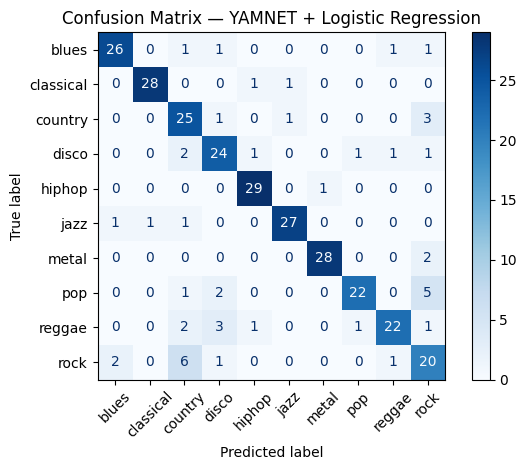


Evaluating encoder: TRILL

Validation Accuracy (TRILL): 0.7567

Classification Report:
              precision    recall  f1-score   support

       blues     0.7500    0.8000    0.7742        30
   classical     0.9000    0.9000    0.9000        30
     country     0.6389    0.7667    0.6970        30
       disco     0.6452    0.6667    0.6557        30
      hiphop     0.8000    0.8000    0.8000        30
        jazz     0.8462    0.7333    0.7857        30
       metal     0.8788    0.9667    0.9206        30
         pop     0.7241    0.7000    0.7119        30
      reggae     0.7500    0.6000    0.6667        30
        rock     0.6552    0.6333    0.6441        30

    accuracy                         0.7567       300
   macro avg     0.7588    0.7567    0.7556       300
weighted avg     0.7588    0.7567    0.7556       300



<Figure size 800x700 with 0 Axes>

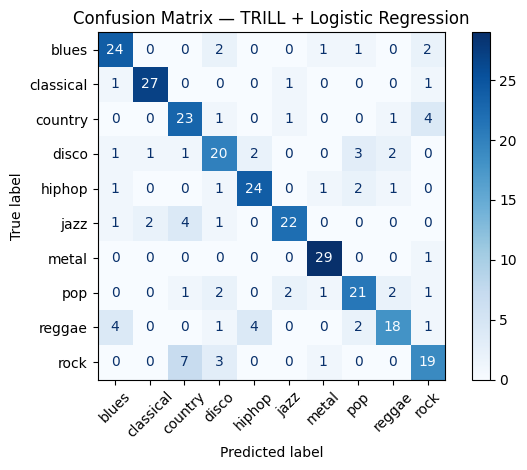


Evaluating encoder: VGGISH

Validation Accuracy (VGGISH): 0.8467

Classification Report:
              precision    recall  f1-score   support

       blues     0.8667    0.8667    0.8667        30
   classical     0.9677    1.0000    0.9836        30
     country     0.7143    0.8333    0.7692        30
       disco     0.7500    0.8000    0.7742        30
      hiphop     0.8529    0.9667    0.9062        30
        jazz     0.9643    0.9000    0.9310        30
       metal     0.9032    0.9333    0.9180        30
         pop     0.8571    0.8000    0.8276        30
      reggae     0.9545    0.7000    0.8077        30
        rock     0.6897    0.6667    0.6780        30

    accuracy                         0.8467       300
   macro avg     0.8520    0.8467    0.8462       300
weighted avg     0.8520    0.8467    0.8462       300



<Figure size 800x700 with 0 Axes>

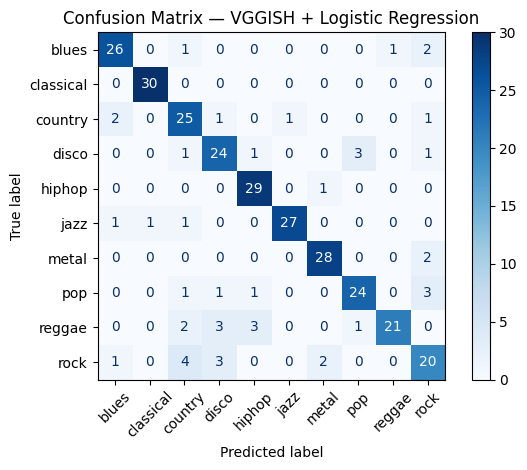

In [ ]:
encoders = ["yamnet", "trill", "vggish"]
classifier_name = "logistic_regression"

results = {}  # store accuracies for comparison

for encoder_name in encoders:
    print("\n" + "="*60)
    print(f"Evaluating encoder: {encoder_name.upper()}")
    print("="*60)

    # 1. Get embeddings + split
    x_train, x_val, y_train, y_val, X, y = pretrain_to_data(
        model=encoder_name,
        directory=DATASET_DIR
    )

    # 2. Train classifier (encoder is frozen)
    clf = LogisticRegression(max_iter=1000)
    clf.fit(x_train, y_train)

    # 3. Predict on validation set
    preds = clf.predict(x_val)

    # 4. Accuracy
    acc = accuracy_score(y_val, preds)
    results[encoder_name] = acc
    print(f"\nValidation Accuracy ({encoder_name.upper()}): {acc:.4f}")

    # 5. Precision / Recall / F1
    print("\nClassification Report:")
    print(classification_report(y_val, preds, target_names=GENRES, digits=4))

    # 6. Confusion Matrix
    cm = confusion_matrix(y_val, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=GENRES)

    plt.figure(figsize=(8, 7))
    disp.plot(cmap="Blues", xticks_rotation=45)
    plt.title(f"Confusion Matrix — {encoder_name.upper()} + Logistic Regression")
    plt.tight_layout()
    plt.show()


In [ ]:
# Compare results numerically
print("\nSummary of Validation Accuracies:")
for k, v in results.items():
    print(f"{k.upper():8s}: {v:.4f}")


Summary of Validation Accuracies:
YAMNET  : 0.8367
TRILL   : 0.7567
VGGISH  : 0.8467


We are using the embeddings extracted from the pre-trained YAMNet encoder that we are freezing
- YAMNet takes each GTZAN audio clip
- Pass it through YAMNet
- YAMNet outputs an embedding matrix (T, 1024) --> one embedding per time framework

## 6b. Train with pytorch classifier head

In [ ]:
# Build classifier head to train
import torch
import torch.nn as nn

class ClassifierHead(nn.Module):
    def __init__(self, input_dim=1024, num_classes=10):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, num_classes)
        )

    def forward(self, x):
        return self.model(x)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import torch

def train_pytorch_classifier(
    encoder_name,
    input_dim,
    directory,
    epochs=15,
    batch_size=32
):
    print("\n" + "="*70)
    print(f"Training PyTorch classifier head — {encoder_name.upper()}")
    print("="*70)

    # --------------------------------------------------
    # 1. Get embeddings
    # --------------------------------------------------
    x_train, x_val, y_train, y_val, X, y = pretrain_to_data(
        model=encoder_name,
        directory=directory
    )

    # --------------------------------------------------
    # 2. Build PyTorch datasets
    # --------------------------------------------------
    train_data = torch.utils.data.TensorDataset(
        torch.tensor(x_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.long)
    )

    val_data = torch.utils.data.TensorDataset(
        torch.tensor(x_val, dtype=torch.float32),
        torch.tensor(y_val, dtype=torch.long)
    )

    train_loader = torch.utils.data.DataLoader(
        train_data, batch_size=batch_size, shuffle=True
    )

    val_loader = torch.utils.data.DataLoader(
        val_data, batch_size=batch_size
    )

    # --------------------------------------------------
    # 3. Initialize classifier head
    # --------------------------------------------------
    device = "cuda" if torch.cuda.is_available() else "cpu"

    clf = ClassifierHead(input_dim=input_dim).to(device)
    optimizer = torch.optim.Adam(clf.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()

    # --------------------------------------------------
    # 4. Training loop
    # --------------------------------------------------
    for epoch in range(epochs):
        clf.train()
        total, correct = 0, 0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            logits = clf(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            optimizer.step()

            preds = torch.argmax(logits, dim=1)
            total += yb.size(0)
            correct += (preds == yb).sum().item()

        train_acc = correct / total

        # Validation
        clf.eval()
        val_correct, val_total = 0, 0

        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = clf(xb)
                preds = torch.argmax(logits, dim=1)
                val_correct += (preds == yb).sum().item()
                val_total += yb.size(0)

        val_acc = val_correct / val_total

        print(f"Epoch {epoch+1:02d} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    # --------------------------------------------------
    # 5. Final evaluation
    # --------------------------------------------------
    clf.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            logits = clf(xb)
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(yb.numpy())

    val_accuracy = accuracy_score(all_labels, all_preds)

    print("\nValidation Accuracy:", val_accuracy)
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=GENRES))

    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=GENRES)

    plt.figure(figsize=(8,7))
    disp.plot(cmap="Blues", xticks_rotation=45)
    plt.title(f"{encoder_name.upper()} + PyTorch Classifier Head")
    plt.tight_layout()
    plt.show()

    return val_accuracy


❗ This will take about 6 minutes.


Training PyTorch classifier head — YAMNET
Epoch 01 | Train Acc: 0.5086 | Val Acc: 0.7433
Epoch 02 | Train Acc: 0.7900 | Val Acc: 0.7667
Epoch 03 | Train Acc: 0.8171 | Val Acc: 0.7833
Epoch 04 | Train Acc: 0.8143 | Val Acc: 0.7833
Epoch 05 | Train Acc: 0.8200 | Val Acc: 0.8067
Epoch 06 | Train Acc: 0.8257 | Val Acc: 0.8067
Epoch 07 | Train Acc: 0.8314 | Val Acc: 0.8067
Epoch 08 | Train Acc: 0.8400 | Val Acc: 0.8133
Epoch 09 | Train Acc: 0.8400 | Val Acc: 0.8100
Epoch 10 | Train Acc: 0.8414 | Val Acc: 0.8133
Epoch 11 | Train Acc: 0.8486 | Val Acc: 0.8167
Epoch 12 | Train Acc: 0.8500 | Val Acc: 0.8133
Epoch 13 | Train Acc: 0.8586 | Val Acc: 0.8133
Epoch 14 | Train Acc: 0.8543 | Val Acc: 0.8133
Epoch 15 | Train Acc: 0.8543 | Val Acc: 0.8200

Validation Accuracy: 0.82

Classification Report:
              precision    recall  f1-score   support

       blues       0.85      0.73      0.79        30
   classical       0.97      1.00      0.98        30
     country       0.68      0.83     

<Figure size 800x700 with 0 Axes>

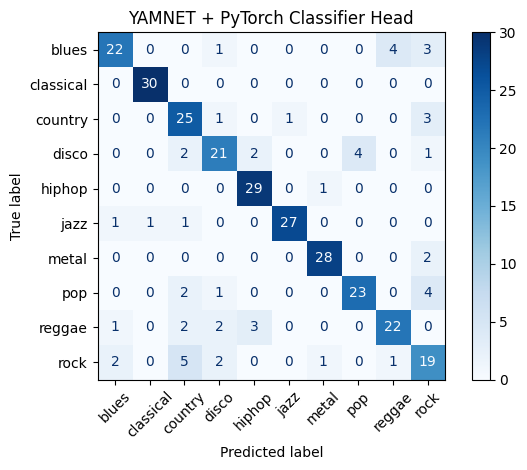


Training PyTorch classifier head — TRILL
Epoch 01 | Train Acc: 0.2757 | Val Acc: 0.4467
Epoch 02 | Train Acc: 0.5886 | Val Acc: 0.6467
Epoch 03 | Train Acc: 0.7386 | Val Acc: 0.6767
Epoch 04 | Train Acc: 0.7543 | Val Acc: 0.6833
Epoch 05 | Train Acc: 0.7657 | Val Acc: 0.6900
Epoch 06 | Train Acc: 0.7671 | Val Acc: 0.6900
Epoch 07 | Train Acc: 0.7757 | Val Acc: 0.6800
Epoch 08 | Train Acc: 0.7700 | Val Acc: 0.6800
Epoch 09 | Train Acc: 0.7743 | Val Acc: 0.6700
Epoch 10 | Train Acc: 0.7757 | Val Acc: 0.6900
Epoch 11 | Train Acc: 0.7814 | Val Acc: 0.6867
Epoch 12 | Train Acc: 0.7871 | Val Acc: 0.6967
Epoch 13 | Train Acc: 0.7900 | Val Acc: 0.6967
Epoch 14 | Train Acc: 0.7900 | Val Acc: 0.7000
Epoch 15 | Train Acc: 0.7943 | Val Acc: 0.6867

Validation Accuracy: 0.6866666666666666

Classification Report:
              precision    recall  f1-score   support

       blues       0.85      0.57      0.68        30
   classical       0.87      0.90      0.89        30
     country       0.49  

<Figure size 800x700 with 0 Axes>

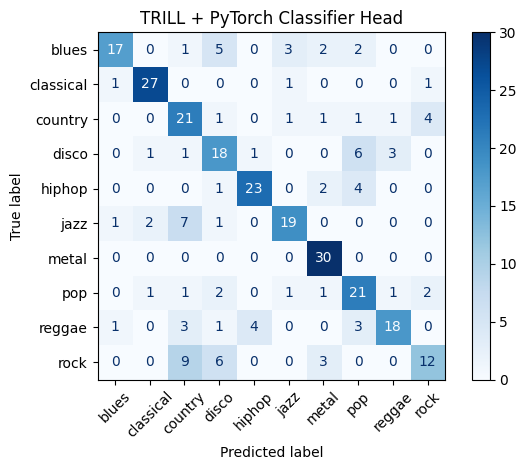


Training PyTorch classifier head — VGGISH
Epoch 01 | Train Acc: 0.1857 | Val Acc: 0.3467
Epoch 02 | Train Acc: 0.4614 | Val Acc: 0.5867
Epoch 03 | Train Acc: 0.6857 | Val Acc: 0.6967
Epoch 04 | Train Acc: 0.7386 | Val Acc: 0.7267
Epoch 05 | Train Acc: 0.7843 | Val Acc: 0.7500
Epoch 06 | Train Acc: 0.7843 | Val Acc: 0.7567
Epoch 07 | Train Acc: 0.7971 | Val Acc: 0.7833
Epoch 08 | Train Acc: 0.8071 | Val Acc: 0.7800
Epoch 09 | Train Acc: 0.8157 | Val Acc: 0.7867
Epoch 10 | Train Acc: 0.8129 | Val Acc: 0.7900
Epoch 11 | Train Acc: 0.8214 | Val Acc: 0.7833
Epoch 12 | Train Acc: 0.8286 | Val Acc: 0.7900
Epoch 13 | Train Acc: 0.8171 | Val Acc: 0.7800
Epoch 14 | Train Acc: 0.8286 | Val Acc: 0.7900
Epoch 15 | Train Acc: 0.8257 | Val Acc: 0.7867

Validation Accuracy: 0.7866666666666666

Classification Report:
              precision    recall  f1-score   support

       blues       0.75      0.70      0.72        30
   classical       0.97      1.00      0.98        30
     country       0.55 

<Figure size 800x700 with 0 Axes>

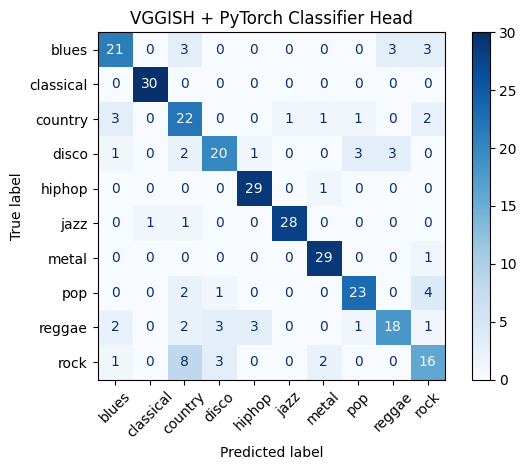

In [ ]:
encoder_configs = {
    "yamnet": 1024,
    "trill": 512,
    "vggish": 128
}

pytorch_results = {}

for encoder_name, input_dim in encoder_configs.items():
    val_acc = train_pytorch_classifier(
        encoder_name=encoder_name,
        input_dim=input_dim,
        directory=DATASET_DIR,
        epochs=15
    )

    pytorch_results[encoder_name] = val_acc


In [ ]:
# Compare results numerically
print("\nSummary of Validation Accuracies (PyTorch Classifier):")
for k, v in pytorch_results.items():
    print(f"{k.upper():8s}: {v:.4f}")


Summary of Validation Accuracies (PyTorch Classifier):
YAMNET  : 0.8200
TRILL   : 0.6867
VGGISH  : 0.7867


## 6c. Compare two classifiers

Logistic Regression YAMNET and VGGISH have higher validation accuracies, compared to PyTorch Classifier.

❗ Running the following code blocks will take about 10 minutes

In [ ]:
# From Mengmeng
import time
from sklearn.linear_model import LogisticRegression

models = ["yamnet", "trill", "vggish"]
directory = "/content/gtzan/genres"

accuracies = {}
embedding_shapes = {}
runtimes = {}

for m in models:
    print(f"\n=== Evaluating {m.upper()} ===")

    start = time.time()   # start timing

    # Extract embeddings + train/val split
    x_train, x_val, y_train, y_val, X, y = pretrain_to_data(m, directory)

    # Record embedding shape
    embedding_shapes[m] = X[0].shape

    # Train linear classifier
    clf = LogisticRegression(max_iter=2000)
    clf.fit(x_train, y_train)

    # Accuracy
    acc = clf.score(x_val, y_val)
    accuracies[m] = acc

    # End timing
    end = time.time()
    runtimes[m] = end - start

    # Print results
    print(f"Embedding shape: {embedding_shapes[m]}")
    print(f"Accuracy: {acc*100:.2f}%")
    print(f"Runtime: {runtimes[m]:.2f} seconds")


=== Evaluating YAMNET ===
Embedding shape: (1024,)
Accuracy: 83.67%
Runtime: 35.10 seconds

=== Evaluating TRILL ===
Embedding shape: (512,)
Accuracy: 75.67%
Runtime: 236.10 seconds

=== Evaluating VGGISH ===
Embedding shape: (128,)
Accuracy: 84.67%
Runtime: 43.26 seconds


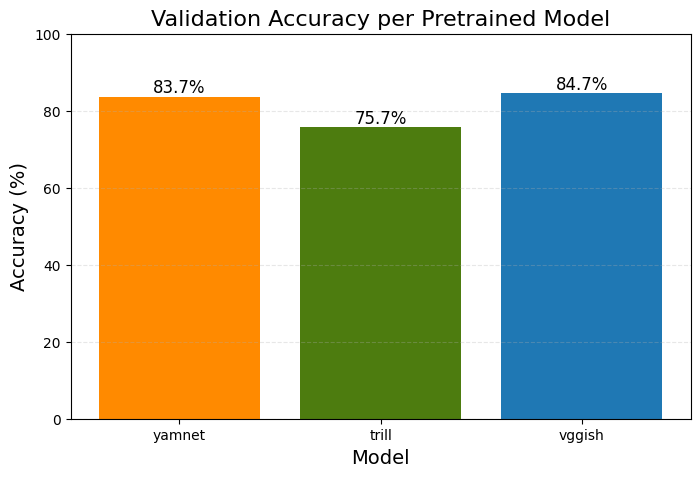

In [ ]:
import matplotlib.pyplot as plt

# Prepare data
model_names = list(accuracies.keys())
acc_values = [accuracies[m] * 100 for m in model_names]  # convert to %
colors = ["#ff8a00", "#4d7c0f", "#1f78b4"]  # optional colors

plt.figure(figsize=(8,5))
plt.bar(model_names, acc_values, color=colors)

# Labels
plt.title("Validation Accuracy per Pretrained Model", fontsize=16)
plt.xlabel("Model", fontsize=14)
plt.ylabel("Accuracy (%)", fontsize=14)

# Accuracy labels on bars
for i, v in enumerate(acc_values):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center', fontsize=12)

plt.ylim(0, 100)
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

In [ ]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


Evaluating encoder: YAMNET

Validation Accuracy (YAMNET): 0.8367

Classification Report:
              precision    recall  f1-score   support

       blues     0.8966    0.8667    0.8814        30
   classical     0.9655    0.9333    0.9492        30
     country     0.6579    0.8333    0.7353        30
       disco     0.7500    0.8000    0.7742        30
      hiphop     0.9062    0.9667    0.9355        30
        jazz     0.9310    0.9000    0.9153        30
       metal     0.9655    0.9333    0.9492        30
         pop     0.9167    0.7333    0.8148        30
      reggae     0.8800    0.7333    0.8000        30
        rock     0.6061    0.6667    0.6349        30

    accuracy                         0.8367       300
   macro avg     0.8475    0.8367    0.8390       300
weighted avg     0.8475    0.8367    0.8390       300



<Figure size 800x700 with 0 Axes>

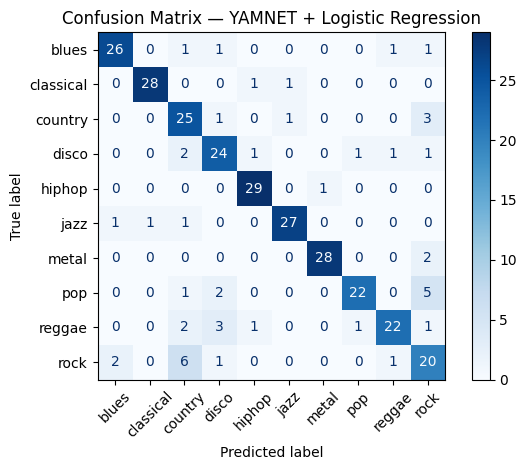


Evaluating encoder: TRILL

Validation Accuracy (TRILL): 0.7567

Classification Report:
              precision    recall  f1-score   support

       blues     0.7500    0.8000    0.7742        30
   classical     0.9000    0.9000    0.9000        30
     country     0.6389    0.7667    0.6970        30
       disco     0.6452    0.6667    0.6557        30
      hiphop     0.8000    0.8000    0.8000        30
        jazz     0.8462    0.7333    0.7857        30
       metal     0.8788    0.9667    0.9206        30
         pop     0.7241    0.7000    0.7119        30
      reggae     0.7500    0.6000    0.6667        30
        rock     0.6552    0.6333    0.6441        30

    accuracy                         0.7567       300
   macro avg     0.7588    0.7567    0.7556       300
weighted avg     0.7588    0.7567    0.7556       300



<Figure size 800x700 with 0 Axes>

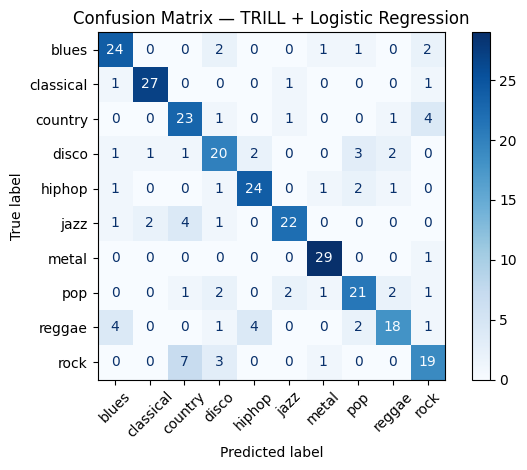


Evaluating encoder: VGGISH

Validation Accuracy (VGGISH): 0.8467

Classification Report:
              precision    recall  f1-score   support

       blues     0.8667    0.8667    0.8667        30
   classical     0.9677    1.0000    0.9836        30
     country     0.7143    0.8333    0.7692        30
       disco     0.7500    0.8000    0.7742        30
      hiphop     0.8529    0.9667    0.9062        30
        jazz     0.9643    0.9000    0.9310        30
       metal     0.9032    0.9333    0.9180        30
         pop     0.8571    0.8000    0.8276        30
      reggae     0.9545    0.7000    0.8077        30
        rock     0.6897    0.6667    0.6780        30

    accuracy                         0.8467       300
   macro avg     0.8520    0.8467    0.8462       300
weighted avg     0.8520    0.8467    0.8462       300



<Figure size 800x700 with 0 Axes>

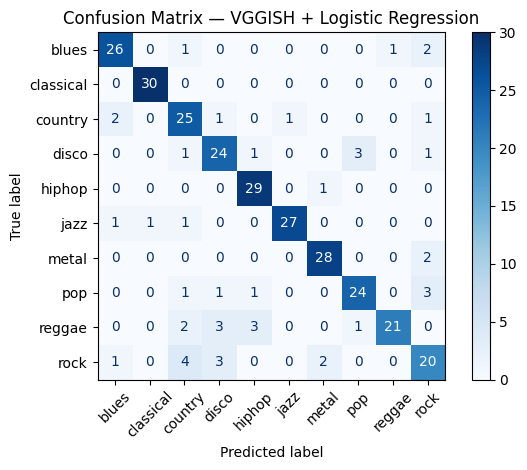

In [ ]:
encoders = ["yamnet", "trill", "vggish"]
classifier_name = "logistic_regression"

results = {}  # store accuracies for comparison

for encoder_name in encoders:
    print("\n" + "="*60)
    print(f"Evaluating encoder: {encoder_name.upper()}")
    print("="*60)

    # 1. Get embeddings + split
    x_train, x_val, y_train, y_val, X, y = pretrain_to_data(
        model=encoder_name,
        directory=DATASET_DIR
    )

    # 2. Train classifier (encoder is frozen)
    clf = LogisticRegression(max_iter=1000)
    clf.fit(x_train, y_train)

    # 3. Predict on validation set
    preds = clf.predict(x_val)

    # 4. Accuracy
    acc = accuracy_score(y_val, preds)
    results[encoder_name] = acc
    print(f"\nValidation Accuracy ({encoder_name.upper()}): {acc:.4f}")

    # 5. Precision / Recall / F1
    print("\nClassification Report:")
    print(classification_report(y_val, preds, target_names=GENRES, digits=4))

    # 6. Confusion Matrix
    cm = confusion_matrix(y_val, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=GENRES)

    plt.figure(figsize=(8, 7))
    disp.plot(cmap="Blues", xticks_rotation=45)
    plt.title(f"Confusion Matrix — {encoder_name.upper()} + Logistic Regression")
    plt.tight_layout()
    plt.show()


In [ ]:
# Compare results numerically
print("\nSummary of Validation Accuracies:")
for k, v in results.items():
    print(f"{k.upper():8s}: {v:.4f}")


Summary of Validation Accuracies:
YAMNET  : 0.8367
TRILL   : 0.7567
VGGISH  : 0.8467


Look at different hyperparameters
- regularization (`C`)
- penalty type (`penalty`)
- class imbalance (`class_weight`)
- convergence (`max_iter`)
- multiclass settings `multi_class='multinomial'`

❗ This will take about 5 minutes.

In [ ]:
import time
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

models = ["yamnet", "trill", "vggish"]
directory = "/content/gtzan/genres"

results = {}

for m in models:
    print("\n" + "="*70)
    print(f"Hyperparameter tuning for encoder: {m.upper()}")
    print("="*70)

    start = time.time()

    # --------------------------------------------------
    # 1. Get embeddings
    # --------------------------------------------------
    x_train, x_val, y_train, y_val, X, y = pretrain_to_data(m, directory)

    # --------------------------------------------------
    # 2. Define pipeline
    # --------------------------------------------------
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(
            max_iter=4000,
            solver="lbfgs",
            multi_class="multinomial"
        ))
    ])

    # --------------------------------------------------
    # 3. Hyperparameter grid
    # --------------------------------------------------
    param_grid = {
        "lr__C": [0.1, 1, 10, 100],
        "lr__class_weight": [None, "balanced"]
    }

    # --------------------------------------------------
    # 4. Grid search (cross-validated)
    # --------------------------------------------------
    grid = GridSearchCV(
        pipe,
        param_grid,
        scoring="accuracy",
        cv=3,
        n_jobs=-1
    )

    grid.fit(x_train, y_train)

    # --------------------------------------------------
    # 5. Evaluate best model on validation set
    # --------------------------------------------------
    best_model = grid.best_estimator_
    val_acc = best_model.score(x_val, y_val)
    val_error = 1 - val_acc

    end = time.time()

    # --------------------------------------------------
    # 6. Store results
    # --------------------------------------------------
    results[m] = {
        "best_params": grid.best_params_,
        "val_accuracy": val_acc,
        "val_error": val_error,
        "runtime_sec": end - start,
        "embedding_shape": X[0].shape
    }

    # --------------------------------------------------
    # 7. Print results
    # --------------------------------------------------
    print("Embedding shape:", X[0].shape)
    print("Best parameters:", grid.best_params_)
    print(f"Validation Accuracy: {val_acc*100:.2f}%")
    print(f"Validation Error: {val_error:.4f}")
    print(f"Runtime: {end - start:.2f} seconds")



Hyperparameter tuning for encoder: YAMNET


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Embedding shape: (1024,)
Best parameters: {'lr__C': 0.1, 'lr__class_weight': None}
Validation Accuracy: 84.33%
Validation Error: 0.1567
Runtime: 52.46 seconds

Hyperparameter tuning for encoder: TRILL


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Embedding shape: (512,)
Best parameters: {'lr__C': 0.1, 'lr__class_weight': None}
Validation Accuracy: 83.00%
Validation Error: 0.1700
Runtime: 236.70 seconds

Hyperparameter tuning for encoder: VGGISH
Embedding shape: (128,)
Best parameters: {'lr__C': 100, 'lr__class_weight': 'balanced'}
Validation Accuracy: 82.00%
Validation Error: 0.1800
Runtime: 33.56 seconds


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Try using PCA before running through logistic regression

❗ This will take some time.

In [ ]:
import time
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA

models = ["yamnet", "trill", "vggish"]
directory = "/content/gtzan/genres"

results = {}

for m in models:
    print("\n" + "="*70)
    print(f"Hyperparameter tuning for encoder: {m.upper()}")
    print("="*70)

    start = time.time()

    # --------------------------------------------------
    # 1. Get embeddings
    # --------------------------------------------------
    x_train, x_val, y_train, y_val, X, y = pretrain_to_data(m, directory)

    # --------------------------------------------------
    # 2. Define pipeline (NOW includes PCA)
    # --------------------------------------------------
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA()),   # n_components will be tuned
        ("lr", LogisticRegression(
            max_iter=4000,
            solver="lbfgs"
        ))
    ])

    # --------------------------------------------------
    # 3. Hyperparameter grid (PCA + LR together)
    # --------------------------------------------------
    param_grid = {
        "pca__n_components": [0.90, 0.95, 0.99],
        "lr__C": [0.01, 0.1, 1, 10],
        "lr__class_weight": [None, "balanced"]
    }

    # --------------------------------------------------
    # 4. Grid search (cross-validated)
    # --------------------------------------------------
    grid = GridSearchCV(
        pipe,
        param_grid,
        scoring="accuracy",
        cv=3,
        n_jobs=-1
    )

    grid.fit(x_train, y_train)

    # --------------------------------------------------
    # 5. Evaluate best model on validation set
    # --------------------------------------------------
    best_model = grid.best_estimator_
    val_acc = best_model.score(x_val, y_val)
    val_error = 1 - val_acc

    end = time.time()

    # --------------------------------------------------
    # 6. Store results
    # --------------------------------------------------
    results[m] = {
        "best_params": grid.best_params_,
        "val_accuracy": val_acc,
        "val_error": val_error,
        "runtime_sec": end - start,
        "embedding_shape": X[0].shape
    }

    # --------------------------------------------------
    # 7. Print results
    # --------------------------------------------------
    print("Embedding shape:", X[0].shape)
    print("Best parameters:", grid.best_params_)
    print(f"Validation Accuracy: {val_acc*100:.2f}%")
    print(f"Validation Error: {val_error:.4f}")
    print(f"Runtime: {end - start:.2f} seconds")



Hyperparameter tuning for encoder: YAMNET
Embedding shape: (1024,)
Best parameters: {'lr__C': 0.1, 'lr__class_weight': None, 'pca__n_components': 0.99}
Validation Accuracy: 82.33%
Validation Error: 0.1767
Runtime: 42.15 seconds

Hyperparameter tuning for encoder: TRILL
Embedding shape: (512,)
Best parameters: {'lr__C': 0.1, 'lr__class_weight': 'balanced', 'pca__n_components': 0.99}
Validation Accuracy: 82.33%
Validation Error: 0.1767
Runtime: 232.68 seconds

Hyperparameter tuning for encoder: VGGISH
Embedding shape: (128,)
Best parameters: {'lr__C': 1, 'lr__class_weight': 'balanced', 'pca__n_components': 0.99}
Validation Accuracy: 83.33%
Validation Error: 0.1667
Runtime: 39.56 seconds


Test PCA vs no PCA

In [ ]:
import time
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold

models = ["yamnet", "trill", "vggish"]
directory = "/content/gtzan/genres"

results = {}

for m in models:
    print("\n" + "="*70)
    print(f"Hyperparameter tuning for encoder: {m.upper()}")
    print("="*70)

    start = time.time()

    # --------------------------------------------------
    # 1. Get embeddings
    # --------------------------------------------------
    x_train, x_val, y_train, y_val, X, y = pretrain_to_data(m, directory)

    # --------------------------------------------------
    # 2. Define pipeline (NOW includes PCA)
    # --------------------------------------------------
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA()),   # n_components will be tuned
        ("lr", LogisticRegression(
            max_iter=4000,
            solver="lbfgs"
        ))
    ])

    # --------------------------------------------------
    # 3. Hyperparameter grid (PCA + LR together)
    # --------------------------------------------------
    param_grid = {
        "pca__n_components": [None, 0.90, 0.95, 0.99],
        "lr__C": [0.01, 0.1, 1, 10],
        "lr__class_weight": [None, "balanced"]
    }

    # --------------------------------------------------
    # 4. Grid search (cross-validated)
    # --------------------------------------------------
    grid = GridSearchCV(
        pipe,
        param_grid,
        scoring="accuracy",
        cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
        n_jobs=-1
    )

    grid.fit(x_train, y_train)

    # --------------------------------------------------
    # 5. Evaluate best model on validation set
    # --------------------------------------------------
    best_model = grid.best_estimator_
    val_acc = best_model.score(x_val, y_val)
    val_error = 1 - val_acc

    end = time.time()

    # --------------------------------------------------
    # 6. Store results
    # --------------------------------------------------
    results[m] = {
        "best_params": grid.best_params_,
        "val_accuracy": val_acc,
        "val_error": val_error,
        "runtime_sec": end - start,
        "embedding_shape": X[0].shape
    }

    # --------------------------------------------------
    # 7. Print results
    # --------------------------------------------------
    print("Embedding shape:", X[0].shape)
    print("Best parameters:", grid.best_params_)
    print(f"Validation Accuracy: {val_acc*100:.2f}%")
    print(f"Validation Error: {val_error:.4f}")
    print(f"Runtime: {end - start:.2f} seconds")

    if grid.best_params_["pca__n_components"] is None:
        print("Best model uses NO PCA")
    else:
        print(f"Best model uses PCA with n_components={grid.best_params_['pca__n_components']}")




Hyperparameter tuning for encoder: YAMNET
Embedding shape: (1024,)
Best parameters: {'lr__C': 0.01, 'lr__class_weight': None, 'pca__n_components': None}
Validation Accuracy: 85.67%
Validation Error: 0.1433
Runtime: 50.18 seconds
Best model uses NO PCA

Hyperparameter tuning for encoder: TRILL
Embedding shape: (512,)
Best parameters: {'lr__C': 10, 'lr__class_weight': None, 'pca__n_components': None}
Validation Accuracy: 81.67%
Validation Error: 0.1833
Runtime: 234.65 seconds
Best model uses NO PCA

Hyperparameter tuning for encoder: VGGISH
Embedding shape: (128,)
Best parameters: {'lr__C': 1, 'lr__class_weight': 'balanced', 'pca__n_components': None}
Validation Accuracy: 82.33%
Validation Error: 0.1767
Runtime: 37.22 seconds
Best model uses NO PCA


# 7. Test data preparation
Process downloaded songs into 30 seconds clips, convert to WAV, store in folder hierarchy based on genre

In [ ]:
!pip install pydub
!apt-get install -y ffmpeg
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os
from pydub import AudioSegment

def extract_middle_30sec(audio):
    """Return the middle 30 seconds of an AudioSegment."""
    duration_ms = len(audio)
    clip_len = 30 * 1000  # 30 seconds

    if duration_ms < clip_len:
        raise ValueError("Audio is shorter than 30 seconds.")

    start_ms = (duration_ms // 2) - (clip_len // 2)
    end_ms = start_ms + clip_len
    return audio[start_ms:end_ms]


def convert_nested_directories(root_input_dir):
    # Remove trailing slash
    root_input_dir = root_input_dir.rstrip("/")

    # Create output folder
    root_output_dir = os.path.join(root_input_dir, "30s_clips")
    os.makedirs(root_output_dir, exist_ok=True)

    print(f"Input root directory:  {root_input_dir}")
    print(f"Output root directory: {root_output_dir}\n")

    # Walk through all folders under root_input_dir
    for current_dir, subdirs, files in os.walk(root_input_dir):
        # Skip the output folder so we don't re-process generated files
        if "30s_clips" in current_dir:
            continue

        # Compute relative folder path under root_input_dir
        rel_path = os.path.relpath(current_dir, root_input_dir)

        # Mirror this path inside root_output_dir
        output_dir = os.path.join(root_output_dir, rel_path)
        os.makedirs(output_dir, exist_ok=True)

        for filename in files:
            if filename.lower().endswith(".mp3"):
                input_path = os.path.join(current_dir, filename)

                # Keep same base name, change extension to .wav
                base_name = os.path.splitext(filename)[0]
                output_path = os.path.join(output_dir, base_name + ".wav")

                try:
                    audio = AudioSegment.from_mp3(input_path)
                    clip = extract_middle_30sec(audio)

                    clip.export(output_path, format="wav")
                    print(f"Saved: {output_path}")
                except Exception as e:
                    print(f"Error processing {input_path}: {e}")

    print("\nDONE — All MP3s converted to 30s WAV clips!")


# ---- Set your project folder on Google Drive ----

root_input_dir = "/content/drive/MyDrive/CS441/final_project"

convert_nested_directories(root_input_dir)

# 8. Test classifier + encoder on test set

## 8a. Load test set

In [ ]:
import os
import librosa
import numpy as np

def load_test_set(directory):
    X_test_audio = []
    y_test = []

    GENRES = sorted(os.listdir(directory))
    GENRE_TO_INDEX = {g: i for i, g in enumerate(GENRES)}

    for genre in GENRES:
        genre_dir = os.path.join(directory, genre)

        for file in os.listdir(genre_dir):
            if file.endswith((".wav", ".mp3", ".au")):
                path = os.path.join(genre_dir, file)
                audio, sr = librosa.load(path, sr=None)

                X_test_audio.append((audio, sr))
                y_test.append(GENRE_TO_INDEX[genre])

    return X_test_audio, np.array(y_test), GENRES


In [ ]:
TEST_DIR = "/content/gdrive/MyDrive/CS 441 Homeworks/Final project/test_set"

X_test_audio, y_test, TEST_GENRES = load_test_set(TEST_DIR)

print("Test samples:", len(X_test_audio))
print("Genres:", TEST_GENRES)


FileNotFoundError: [Errno 2] No such file or directory: '/content/test_set'

## 8b. Get extracted test embeddings (frozen encoder)

In [ ]:
TEST_DIR = "/content/gdrive/MyDrive/CS 441 Homeworks/Final project/test_set"
print("Test genres:", os.listdir(TEST_DIR))
for g in os.listdir(TEST_DIR):
    print(g, "files:", len(os.listdir(os.path.join(TEST_DIR, g))))


Test genres: ['country', 'reggae', 'hiphop', 'disco', 'rock', 'blues', 'jazz', 'metal', 'pop', 'classical']
country files: 20
reggae files: 20
hiphop files: 20
disco files: 20
rock files: 20
blues files: 20
jazz files: 20
metal files: 20
pop files: 20
classical files: 20


In [ ]:
import numpy as np
import os

def extract_test_embeddings(model_name, test_directory):
    X_test = []
    y_test = []

    GENRES = sorted(os.listdir(test_directory))
    GENRE_TO_INDEX = {g: i for i, g in enumerate(GENRES)}

    for genre in GENRES:
        folder = os.path.join(test_directory, genre)

        for filename in os.listdir(folder):
            if filename.lower().endswith((".au", ".wav", ".mp3")):
                filepath = os.path.join(folder, filename)

                emb = extract_embedding(filepath, model_name)
                X_test.append(emb)
                y_test.append(GENRE_TO_INDEX[genre])

    X_test = np.array(X_test)
    y_test = np.array(y_test)

    print("X_test shape:", X_test.shape)
    print("y_test shape:", y_test.shape)

    return X_test, y_test


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Combine train + validation
X_full = np.vstack([x_train, x_val])
y_full = np.hstack([y_train, y_val])

final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        C=0.01,
        max_iter=4000,
        solver="lbfgs",
        class_weight=None
    ))
])

final_model.fit(X_full, y_full)


Pipeline(steps=[('scaler', StandardScaler()),
                ('lr', LogisticRegression(C=0.01, max_iter=4000))])

❗ This will take some time.

In [ ]:
TEST_DIR = "/content/gdrive/MyDrive/CS 441 Homeworks/Final project/test_set"

X_test, y_test = extract_test_embeddings(
    model_name="yamnet",
    test_directory=TEST_DIR
)


X_test shape: (200, 1024)
y_test shape: (200,)


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA
import time

models = ["yamnet", "trill", "vggish"]
directory = "/content/gtzan/genres"

best_models = {}
results = {}

for m in models:
    print("\n" + "="*70)
    print(f"Hyperparameter tuning for encoder: {m.upper()}")
    print("="*70)

    start = time.time()

    # 1. Get embeddings
    x_train, x_val, y_train, y_val, X, y = pretrain_to_data(m, directory)

    # 2. Pipeline: scaler + optional PCA + logistic regression
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA()),  # can be bypassed via None
        ("lr", LogisticRegression(
            max_iter=4000,
            solver="lbfgs"
        ))
    ])

    # 3. Grid (PCA vs no PCA)
    param_grid = {
        "pca__n_components": [None, 0.90, 0.95, 0.99],
        "lr__C": [0.01, 0.1, 1, 10],
        "lr__class_weight": [None, "balanced"]
    }

    # 4. Grid search
    grid = GridSearchCV(
        pipe,
        param_grid,
        scoring="accuracy",
        cv=3,
        n_jobs=-1
    )

    grid.fit(x_train, y_train)

    # 5. Store best model
    best_model = grid.best_estimator_
    best_models[m] = best_model

    val_acc = best_model.score(x_val, y_val)
    val_error = 1 - val_acc

    end = time.time()

    results[m] = {
        "best_params": grid.best_params_,
        "val_accuracy": val_acc,
        "val_error": val_error,
        "runtime_sec": end - start,
        "embedding_shape": X[0].shape
    }

    print("Embedding shape:", X[0].shape)
    print("Best parameters:", grid.best_params_)
    print(f"Validation Accuracy: {val_acc*100:.2f}%")
    print(f"Validation Error: {val_error:.4f}")
    print(f"Runtime: {end - start:.2f} seconds")



Hyperparameter tuning for encoder: YAMNET
Embedding shape: (1024,)
Best parameters: {'lr__C': 0.1, 'lr__class_weight': None, 'pca__n_components': None}
Validation Accuracy: 84.33%
Validation Error: 0.1567
Runtime: 46.80 seconds

Hyperparameter tuning for encoder: TRILL
Embedding shape: (512,)
Best parameters: {'lr__C': 0.1, 'lr__class_weight': 'balanced', 'pca__n_components': 0.99}
Validation Accuracy: 82.33%
Validation Error: 0.1767
Runtime: 233.04 seconds

Hyperparameter tuning for encoder: VGGISH
Embedding shape: (128,)
Best parameters: {'lr__C': 1, 'lr__class_weight': 'balanced', 'pca__n_components': 0.99}
Validation Accuracy: 83.33%
Validation Error: 0.1667
Runtime: 35.60 seconds


TEST ACCURACY: 0.51

TEST CLASSIFICATION REPORT:
              precision    recall  f1-score   support

       blues       0.37      0.35      0.36        20
   classical       0.94      0.75      0.83        20
     country       0.48      0.60      0.53        20
       disco       0.88      0.35      0.50        20
      hiphop       0.54      0.35      0.42        20
        jazz       0.57      0.40      0.47        20
       metal       0.64      0.90      0.75        20
         pop       0.38      0.70      0.49        20
      reggae       0.55      0.30      0.39        20
        rock       0.28      0.40      0.33        20

    accuracy                           0.51       200
   macro avg       0.56      0.51      0.51       200
weighted avg       0.56      0.51      0.51       200



<Figure size 800x700 with 0 Axes>

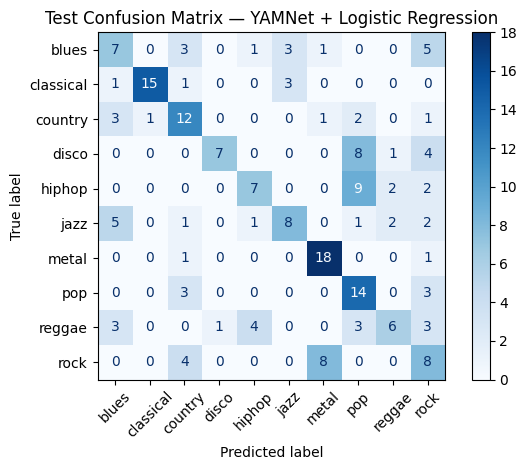

In [ ]:
final_model = best_models["yamnet"]

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict
test_preds = final_model.predict(X_test)

# Accuracy
print("TEST ACCURACY:", accuracy_score(y_test, test_preds))

# Classification report
print("\nTEST CLASSIFICATION REPORT:")
print(classification_report(y_test, test_preds, target_names=GENRES))

# Confusion matrix
cm = confusion_matrix(y_test, test_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=GENRES)

plt.figure(figsize=(8,7))
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Test Confusion Matrix — YAMNet + Logistic Regression")
plt.tight_layout()
plt.show()


<Figure size 800x700 with 0 Axes>

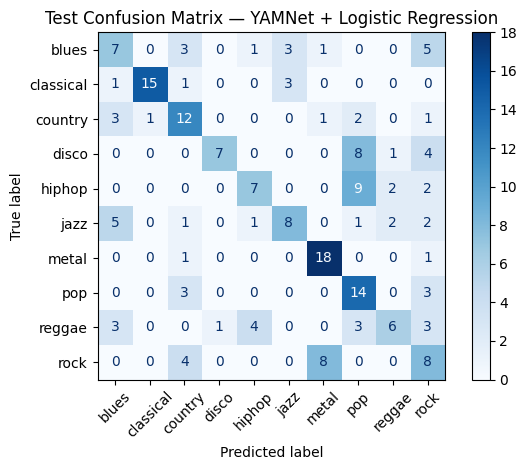

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, test_preds)

disp = ConfusionMatrixDisplay(cm, display_labels=GENRES)
plt.figure(figsize=(8,7))
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Test Confusion Matrix — YAMNet + Logistic Regression")
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np

unique, counts = np.unique(test_preds, return_counts=True)
for u, c in zip(unique, counts):
    print(GENRES[u], c)


blues 19
classical 16
country 25
disco 8
hiphop 13
jazz 14
metal 28
pop 37
reggae 11
rock 29


# Final Testing Results

In [ ]:
final_model = best_models["yamnet"]   # sklearn Pipeline

test_preds = final_model.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

print("TEST ACCURACY:", accuracy_score(y_test, test_preds))
print("\nTEST CLASSIFICATION REPORT:")
print(classification_report(y_test, test_preds, target_names=GENRES))


TEST ACCURACY: 0.51

TEST CLASSIFICATION REPORT:
              precision    recall  f1-score   support

       blues       0.37      0.35      0.36        20
   classical       0.94      0.75      0.83        20
     country       0.48      0.60      0.53        20
       disco       0.88      0.35      0.50        20
      hiphop       0.54      0.35      0.42        20
        jazz       0.57      0.40      0.47        20
       metal       0.64      0.90      0.75        20
         pop       0.38      0.70      0.49        20
      reggae       0.55      0.30      0.39        20
        rock       0.28      0.40      0.33        20

    accuracy                           0.51       200
   macro avg       0.56      0.51      0.51       200
weighted avg       0.56      0.51      0.51       200



## Look at training examples

In [ ]:
GENRES = [
    "blues", "classical", "country", "disco", "hiphop",
    "jazz", "metal", "pop", "reggae", "rock"
]

GENRE_TO_INDEX = {g: i for i, g in enumerate(GENRES)}
INDEX_TO_GENRE = {i: g for g, i in GENRE_TO_INDEX.items()}


In [ ]:
import os

TRAIN_DIR = "/content/gtzan/genres"

# Pick a genre + one file
true_genre = "blues"
song_file = os.listdir(os.path.join(TRAIN_DIR, true_genre))[0]

song_path = os.path.join(TRAIN_DIR, true_genre, song_file)

print("Song path:", song_path)
print("True label:", true_genre)

#---------

import librosa
import numpy as np

audio, sr = librosa.load(song_path, sr=None)

# Extract pooled YAMNet embedding
song_embedding = extract_yamnet_embedding(audio, sr)

# Must be 2D for sklearn: (1, 1024)
song_embedding = song_embedding.reshape(1, -1)

print("Embedding shape:", song_embedding.shape)


# -------
final_model = best_models["yamnet"]

# Predict class index
pred_idx = final_model.predict(song_embedding)[0]

# Convert index → genre
pred_genre = INDEX_TO_GENRE[pred_idx]

print("Predicted genre:", pred_genre)


In [ ]:
import os

TRAIN_DIR = "/content/gtzan/genres"

# Pick a genre + one file
true_genre = "classical"
song_file = os.listdir(os.path.join(TRAIN_DIR, true_genre))[0]

song_path = os.path.join(TRAIN_DIR, true_genre, song_file)

print("Song path:", song_path)
print("True label:", true_genre)

# ------

import librosa
import numpy as np

audio, sr = librosa.load(song_path, sr=None)

# Extract pooled YAMNet embedding
song_embedding = extract_yamnet_embedding(audio, sr)

# Must be 2D for sklearn: (1, 1024)
song_embedding = song_embedding.reshape(1, -1)

print("Embedding shape:", song_embedding.shape)

# ----
final_model = best_models["yamnet"]

# Predict class index
pred_idx = final_model.predict(song_embedding)[0]

# Convert index → genre
pred_genre = INDEX_TO_GENRE[pred_idx]

print("Predicted genre:", pred_genre)


In [ ]:
import os

TRAIN_DIR = "/content/gtzan/genres"

# Pick a genre + one file
true_genre = "rock"
song_file = os.listdir(os.path.join(TRAIN_DIR, true_genre))[0]

song_path = os.path.join(TRAIN_DIR, true_genre, song_file)

print("Song path:", song_path)
print("True label:", true_genre)

# ------

import librosa
import numpy as np

audio, sr = librosa.load(song_path, sr=None)

# Extract pooled YAMNet embedding
song_embedding = extract_yamnet_embedding(audio, sr)

# Must be 2D for sklearn: (1, 1024)
song_embedding = song_embedding.reshape(1, -1)

print("Embedding shape:", song_embedding.shape)

# ----
final_model = best_models["yamnet"]

# Predict class index
pred_idx = final_model.predict(song_embedding)[0]

# Convert index → genre
pred_genre = INDEX_TO_GENRE[pred_idx]

print("Predicted genre:", pred_genre)


In [ ]:
import os

TRAIN_DIR = "/content/gtzan/genres"

# Pick a genre + one file
true_genre = "pop"
song_file = os.listdir(os.path.join(TRAIN_DIR, true_genre))[0]

song_path = os.path.join(TRAIN_DIR, true_genre, song_file)

print("Song path:", song_path)
print("True label:", true_genre)

# ------

import librosa
import numpy as np

audio, sr = librosa.load(song_path, sr=None)

# Extract pooled YAMNet embedding
song_embedding = extract_yamnet_embedding(audio, sr)

# Must be 2D for sklearn: (1, 1024)
song_embedding = song_embedding.reshape(1, -1)

print("Embedding shape:", song_embedding.shape)

# ----
final_model = best_models["yamnet"]

# Predict class index
pred_idx = final_model.predict(song_embedding)[0]

# Convert index → genre
pred_genre = INDEX_TO_GENRE[pred_idx]

print("Predicted genre:", pred_genre)


## Look at test examples

In [ ]:
import os

TEST_DIR = "/content/gdrive/MyDrive/CS 441 Homeworks/Final project/test_set"

# Pick a genre + one test file
true_genre = "classical"   # change if you want
song_file = os.listdir(os.path.join(TEST_DIR, true_genre))[0]

song_path = os.path.join(TEST_DIR, true_genre, song_file)

print("Song path:", song_path)
print("True label:", true_genre)


# ----------

import librosa
import numpy as np

audio, sr = librosa.load(song_path, sr=None)

# Extract pooled YAMNet embedding
song_embedding = extract_yamnet_embedding(audio, sr)

# Must be 2D for sklearn: (1, 1024)
song_embedding = song_embedding.reshape(1, -1)

print("Embedding shape:", song_embedding.shape)

# ----------
final_model = best_models["yamnet"]

# Predict class index
pred_idx = final_model.predict(song_embedding)[0]

# Convert index → genre
pred_genre = INDEX_TO_GENRE[pred_idx]

print("Predicted genre:", pred_genre)


In [ ]:
import os

TEST_DIR = "/content/gdrive/MyDrive/CS 441 Homeworks/Final project/test_set"

# Pick a genre + one test file
true_genre = "rock"   # change if you want
song_file = os.listdir(os.path.join(TEST_DIR, true_genre))[0]

song_path = os.path.join(TEST_DIR, true_genre, song_file)

print("Song path:", song_path)
print("True label:", true_genre)


# ----------

import librosa
import numpy as np

audio, sr = librosa.load(song_path, sr=None)

# Extract pooled YAMNet embedding
song_embedding = extract_yamnet_embedding(audio, sr)

# Must be 2D for sklearn: (1, 1024)
song_embedding = song_embedding.reshape(1, -1)

print("Embedding shape:", song_embedding.shape)

# ----------
final_model = best_models["yamnet"]

# Predict class index
pred_idx = final_model.predict(song_embedding)[0]

# Convert index → genre
pred_genre = INDEX_TO_GENRE[pred_idx]

print("Predicted genre:", pred_genre)


In [ ]:
import os

TEST_DIR = "/content/gdrive/MyDrive/CS 441 Homeworks/Final project/test_set"

# Pick a genre + one test file
true_genre = "pop"   # change if you want
song_file = os.listdir(os.path.join(TEST_DIR, true_genre))[0]

song_path = os.path.join(TEST_DIR, true_genre, song_file)

print("Song path:", song_path)
print("True label:", true_genre)


# ----------

import librosa
import numpy as np

audio, sr = librosa.load(song_path, sr=None)

# Extract pooled YAMNet embedding
song_embedding = extract_yamnet_embedding(audio, sr)

# Must be 2D for sklearn: (1, 1024)
song_embedding = song_embedding.reshape(1, -1)

print("Embedding shape:", song_embedding.shape)

# ----------
final_model = best_models["yamnet"]

# Predict class index
pred_idx = final_model.predict(song_embedding)[0]

# Convert index → genre
pred_genre = INDEX_TO_GENRE[pred_idx]

print("Predicted genre:", pred_genre)
